# 1

In [26]:
import pandas as pd

df = pd.read_csv('ratings_matrix_large.csv', index_col=0)
df.head()

,HP1,HP2,HP3,TW,SW1,SW2,SW3
0,3.0,2.0,2.0,5.0,2.0,NaN,3.0
1,3.0,5.0,1.0,2.0,5.0,3.0,5.0
2,NaN,4.0,4.0,2.0,5.0,5.0,2.0
3,4.0,3.0,NaN,5.0,2.0,4.0,NaN
4,2.0,4.0,5.0,1.0,3.0,2.0,4.0


# 2

In [27]:
# Fill NaN with 0 for simplicity (or keep NaN for algorithms that handle them)
ratings = df.copy()

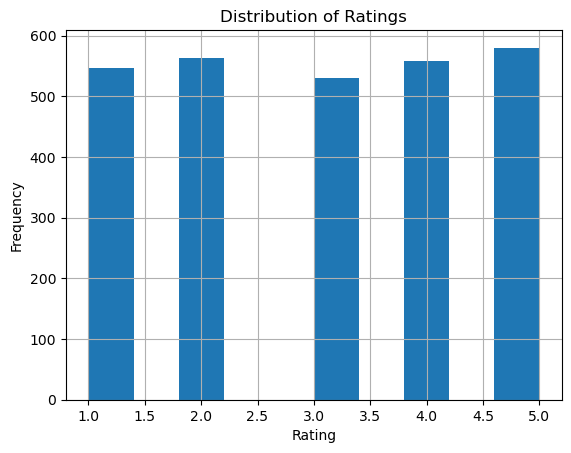

In [28]:
import matplotlib.pyplot as plt

ratings.stack().hist(bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


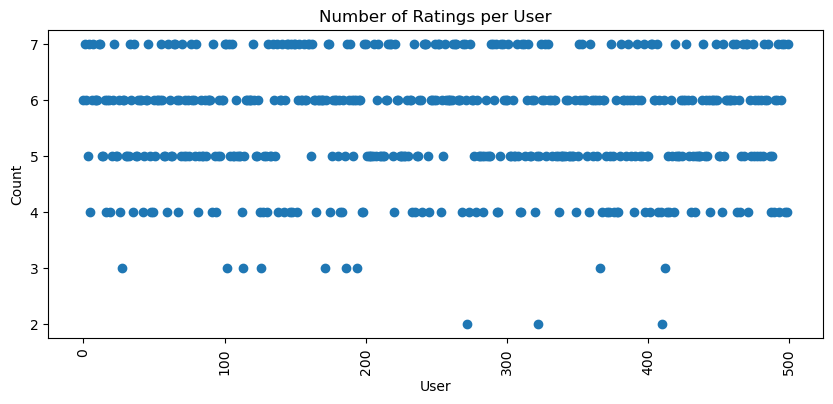

In [29]:
user_activity = ratings.count(axis=1)
plt.figure(figsize=(10, 4))
plt.scatter(user_activity.index, user_activity.values)
plt.title('Number of Ratings per User')
plt.xlabel('User')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


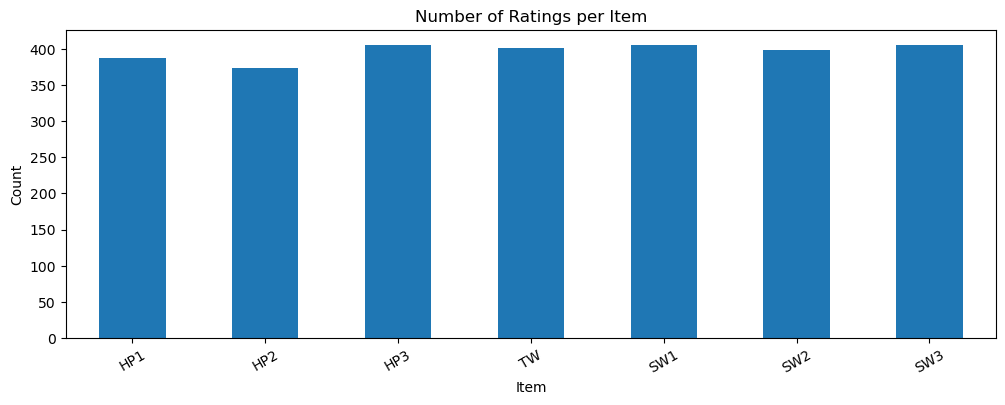

In [30]:
item_popularity = ratings.count()
item_popularity.plot(kind='bar', figsize=(12, 4))
plt.title('Number of Ratings per Item')
plt.xlabel('Item')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()


# 3

In [31]:
global_mean = ratings.stack().mean()
user_bias = ratings.mean(axis=1) - global_mean
item_bias = ratings.mean(axis=0) - global_mean

def global_baseline_estimate(u, i):
    return global_mean + user_bias.get(u, 0) + item_bias.get(i, 0)

# Example usage:
# prediction = global_baseline_estimate('A', 'SW1')


# 4

In [32]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

user_sim = pd.DataFrame(cosine_similarity(ratings.fillna(0)), 
                        index=ratings.index, columns=ratings.index)

def predict_user_user(u, i):
    sims = user_sim[u].drop(u).sort_values(ascending=False)
    numer = 0
    denom = 0
    for v in sims.index:
        if pd.notna(ratings.loc[v, i]):
            numer += sims[v] * ratings.loc[v, i]
            denom += abs(sims[v])
    return numer / denom if denom != 0 else global_mean


# 5

In [33]:
item_sim = pd.DataFrame(cosine_similarity(ratings.fillna(0).T), 
                        index=ratings.columns, columns=ratings.columns)

def predict_item_item(u, i):
    sims = item_sim[i].drop(i).sort_values(ascending=False)
    numer = 0
    denom = 0
    for j in sims.index:
        if pd.notna(ratings.loc[u, j]):
            numer += sims[j] * ratings.loc[u, j]
            denom += abs(sims[j])
    return numer / denom if denom != 0 else global_mean


# 6

In [34]:
from sklearn.metrics import mean_squared_error
from math import sqrt

def evaluate(predict_fn, test_data):
    true_vals = []
    pred_vals = []
    for u in ratings.index:
        for i in ratings.columns:
            if pd.isna(ratings.loc[u, i]):
                continue
            pred = predict_fn(u, i)
            true_vals.append(ratings.loc[u, i])
            pred_vals.append(pred)
    rmse = sqrt(mean_squared_error(true_vals, pred_vals))
    return rmse

# Example usage:
# evaluate(global_baseline_estimate, ratings)


# 7

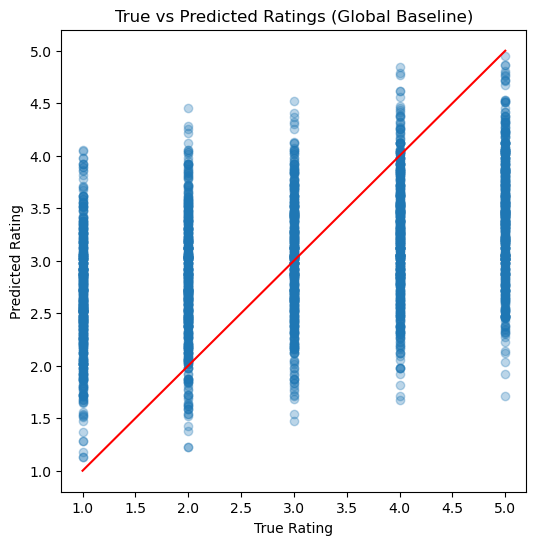

In [35]:
true_vals = []
pred_vals = []

for u in ratings.index:
    for i in ratings.columns:
        if pd.notna(ratings.loc[u, i]):
            true_vals.append(ratings.loc[u, i])
            pred_vals.append(global_baseline_estimate(u, i))

plt.figure(figsize=(6, 6))
plt.scatter(true_vals, pred_vals, alpha=0.3)
plt.title('True vs Predicted Ratings (Global Baseline)')
plt.xlabel('True Rating')
plt.ylabel('Predicted Rating')
plt.plot([min(true_vals), max(true_vals)], [min(true_vals), max(true_vals)], color='red')
plt.show()


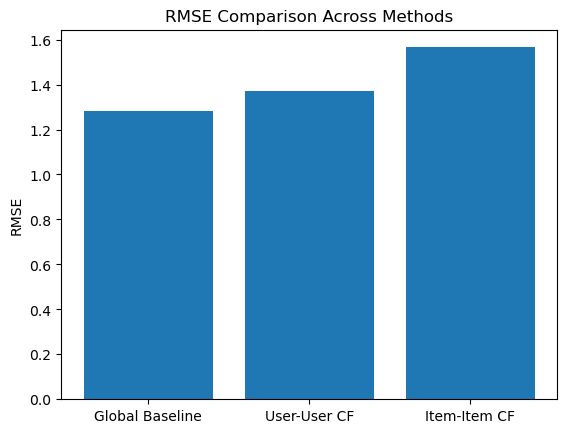

In [36]:
rmse_scores = {
    'Global Baseline': evaluate(global_baseline_estimate, ratings),
    'User-User CF': evaluate(predict_user_user, ratings),
    'Item-Item CF': evaluate(predict_item_item, ratings)
}

plt.bar(rmse_scores.keys(), rmse_scores.values())
plt.title('RMSE Comparison Across Methods')
plt.ylabel('RMSE')
plt.show()


In [37]:
def evaluate_on_missing(predict_fn, ratings_original):
    true_vals = []
    pred_vals = []
    for u in ratings_original.index:
        for i in ratings_original.columns:
            if pd.isna(ratings_original.loc[u, i]):
                continue
            # Simulate prediction as if it were missing
            pred = predict_fn(u, i)
            true_vals.append(ratings_original.loc[u, i])
            pred_vals.append(pred)
    return sqrt(mean_squared_error(true_vals, pred_vals))

# Example usage:
rmse_baseline = evaluate_on_missing(global_baseline_estimate, ratings)
rmse_user = evaluate_on_missing(predict_user_user, ratings)
rmse_item = evaluate_on_missing(predict_item_item, ratings)

print("RMSE - Global Baseline:", rmse_baseline)
print("RMSE - User-User CF:", rmse_user)
print("RMSE - Item-Item CF:", rmse_item)


RMSE - Global Baseline: 1.2819326271701084
RMSE - User-User CF: 1.37150299624995
RMSE - Item-Item CF: 1.5659245217834163


In [38]:
# Apply Global Baseline
global_baseline_preds = ratings.copy()
for u in ratings.index:
    for i in ratings.columns:
        if pd.isna(ratings.loc[u, i]):
            global_baseline_preds.loc[u, i] = global_baseline_estimate(u, i)

# Apply User-User Collaborative Filtering
user_user_preds = ratings.copy()
for u in ratings.index:
    for i in ratings.columns:
        if pd.isna(ratings.loc[u, i]):
            user_user_preds.loc[u, i] = predict_user_user(u, i)

# Apply Item-Item Collaborative Filtering
item_item_preds = ratings.copy()
for u in ratings.index:
    for i in ratings.columns:
        if pd.isna(ratings.loc[u, i]):
            item_item_preds.loc[u, i] = predict_item_item(u, i)


In [39]:
global_baseline_preds.to_csv('global_baseline_predictions.csv')
user_user_preds.to_csv('user_user_predictions.csv')
item_item_preds.to_csv('item_item_predictions.csv')


In [40]:
# Load the CSV files
global_baseline_csv = pd.read_csv('global_baseline_predictions.csv')
user_user_csv = pd.read_csv('user_user_predictions.csv')
item_item_csv = pd.read_csv('item_item_predictions.csv')

# Check for missing values
print("Missing values in Global Baseline Predictions CSV:")
print(global_baseline_csv.isnull().sum())

print("\nMissing values in User-User Predictions CSV:")
print(user_user_csv.isnull().sum())

print("\nMissing values in Item-Item Predictions CSV:")
print(item_item_csv.isnull().sum())

Missing values in Global Baseline Predictions CSV:
Unnamed: 0    0
HP1           0
HP2           0
HP3           0
TW            0
SW1           0
SW2           0
SW3           0
dtype: int64

Missing values in User-User Predictions CSV:
Unnamed: 0    0
HP1           0
HP2           0
HP3           0
TW            0
SW1           0
SW2           0
SW3           0
dtype: int64

Missing values in Item-Item Predictions CSV:
Unnamed: 0    0
HP1           0
HP2           0
HP3           0
TW            0
SW1           0
SW2           0
SW3           0
dtype: int64
